/tmp/ipykernel_3250/2342504041.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='category_name', order=order, palette='magma')


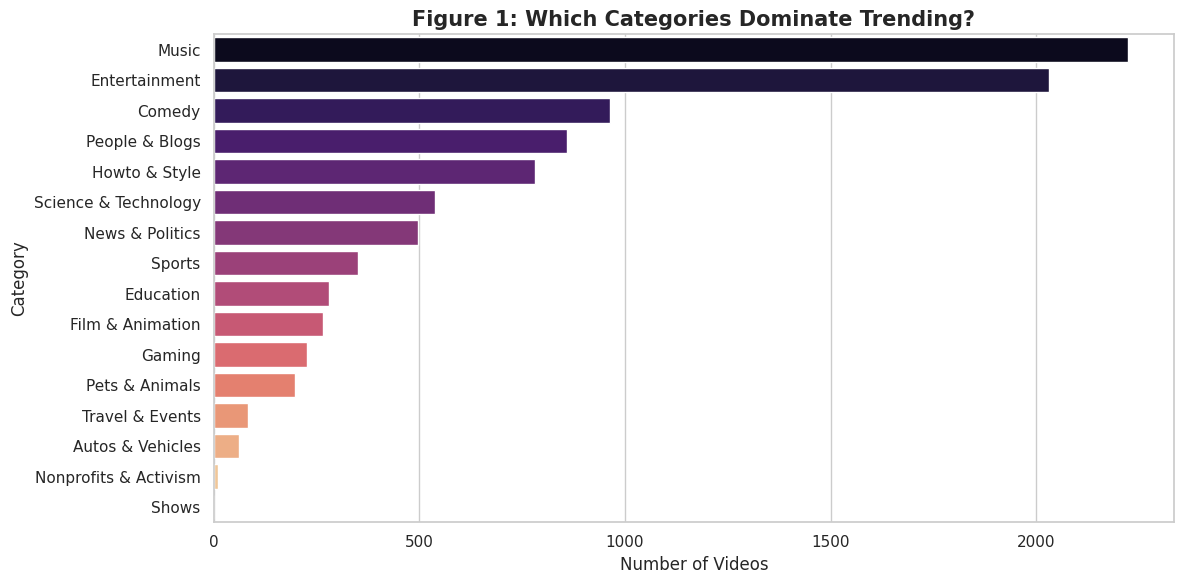

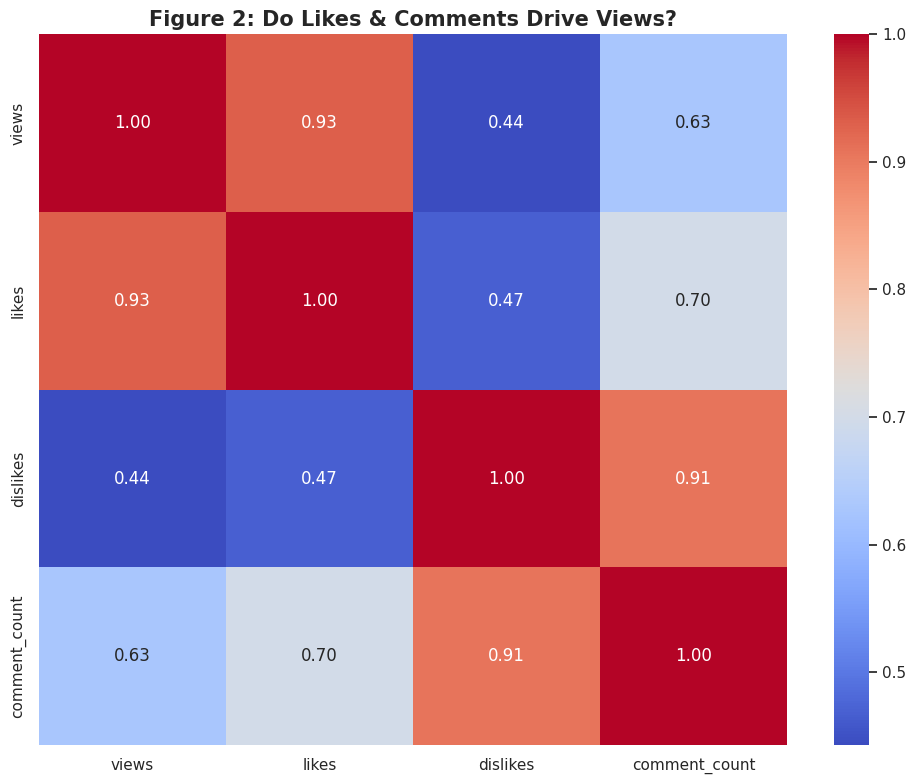

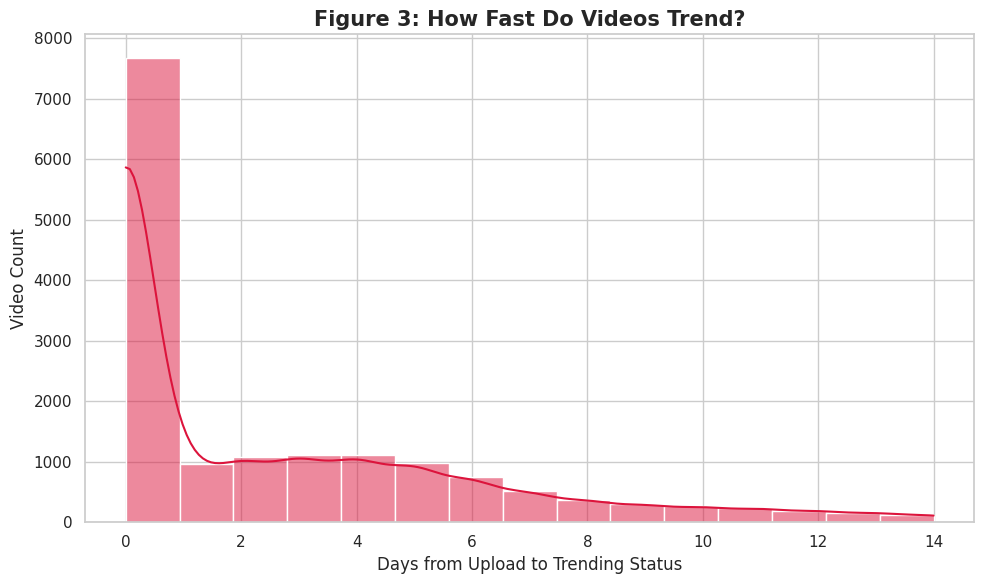


SUCCESS: All visualizations generated.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

try:
    df = pd.read_csv('/content/USvideos.csv',
                     quoting=3,
                     on_bad_lines='skip',
                     engine='python',
                     encoding='utf-8')

    with open('/content/US_category_id.json', 'r') as f:
        categories_data = json.load(f)
    df.columns = [c.replace('"', '').strip() for c in df.columns]

    id_to_cat = {item['id']: item['snippet']['title'] for item in categories_data['items']}
    df['category_name'] = df['category_id'].astype(str).map(id_to_cat)

    df['trending_date'] = pd.to_datetime(df['trending_date'], format='%y.%d.%m', errors='coerce')
    df['publish_time'] = pd.to_datetime(df['publish_time'], errors='coerce')

    df['publish_time'] = df['publish_time'].dt.tz_localize(None)

    df['days_to_trend'] = (df['trending_date'] - df['publish_time']).dt.days
    df['days_to_trend'] = df['days_to_trend'].fillna(0).clip(lower=0)

    for col in ['views', 'likes', 'dislikes', 'comment_count']:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

    sns.set_theme(style="whitegrid")

    plt.figure(figsize=(12, 6))
    order = df['category_name'].value_counts().index
    sns.countplot(data=df, y='category_name', order=order, palette='magma')
    plt.title('Figure 1: Which Categories Dominate Trending?', fontsize=15, fontweight='bold')
    plt.xlabel('Number of Videos')
    plt.ylabel('Category')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 8))
    corr = df[['views', 'likes', 'dislikes', 'comment_count']].corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Figure 2: Do Likes & Comments Drive Views?', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    sns.histplot(df[df['days_to_trend'] <= 14]['days_to_trend'], bins=15, kde=True, color='crimson')
    plt.title('Figure 3: How Fast Do Videos Trend?', fontsize=15, fontweight='bold')
    plt.xlabel('Days from Upload to Trending Status')
    plt.ylabel('Video Count')
    plt.tight_layout()
    plt.show()

    print("\nSUCCESS: All visualizations generated.")

except Exception as e:
    print(f"\nCRITICAL ERROR: {e}")

Starting Universal Data Merge...
Loaded CA successfully.
Loaded DE successfully.
Loaded FR successfully.
Loaded GB successfully.
Loaded KR successfully.
Loaded MX successfully.
Loaded RU successfully.
Loaded US successfully.

Rendering All 11 Figures...


/tmp/ipykernel_847/2730004493.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='category_name', order=df['category_name'].value_counts().index, palette='magma')


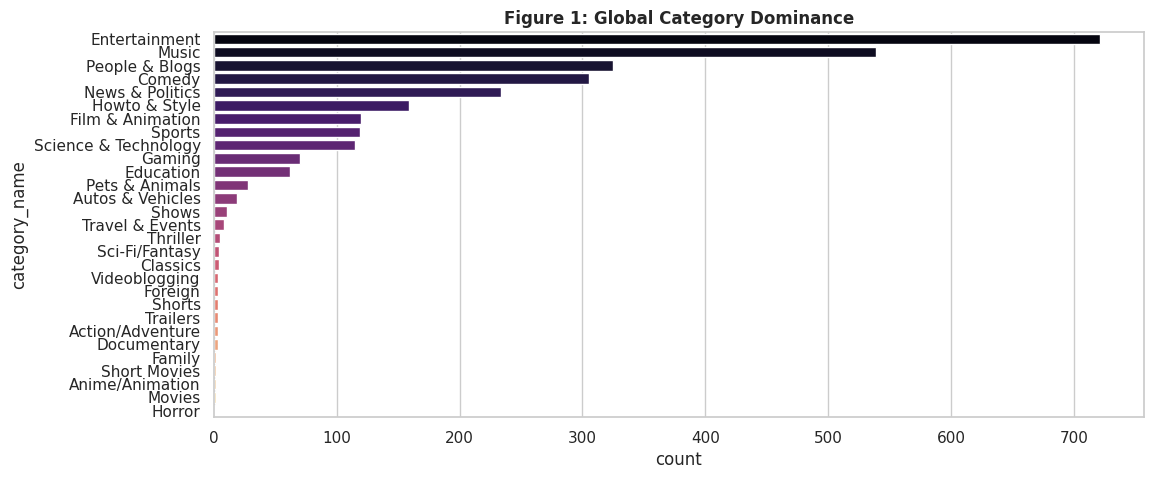

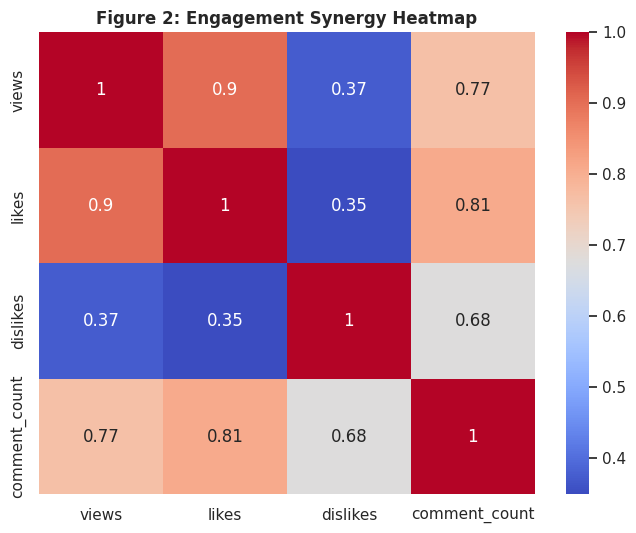

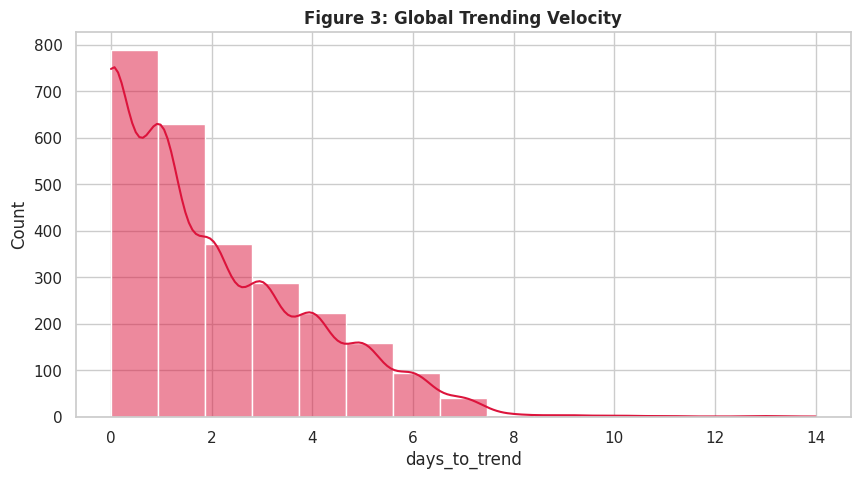

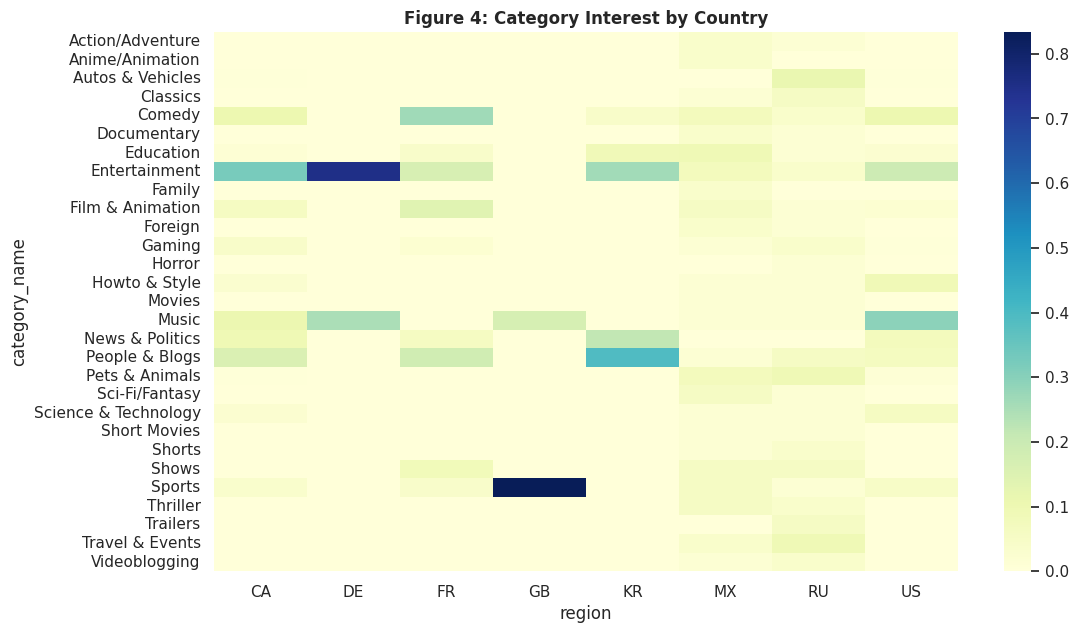

/tmp/ipykernel_847/2730004493.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='region', y='like_ratio', palette='viridis', estimator=np.median)


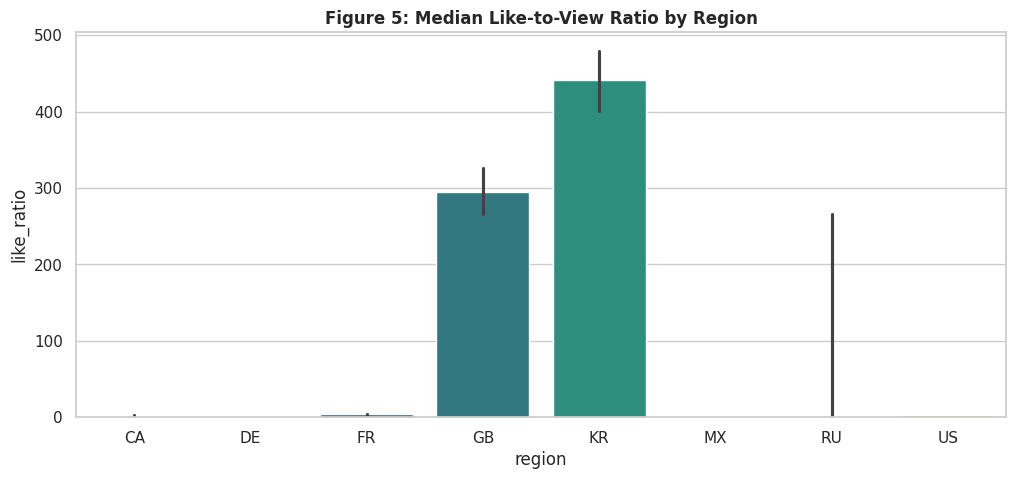

/tmp/ipykernel_847/2730004493.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='region', y='days_to_trend', palette='Set2', showfliers=False)


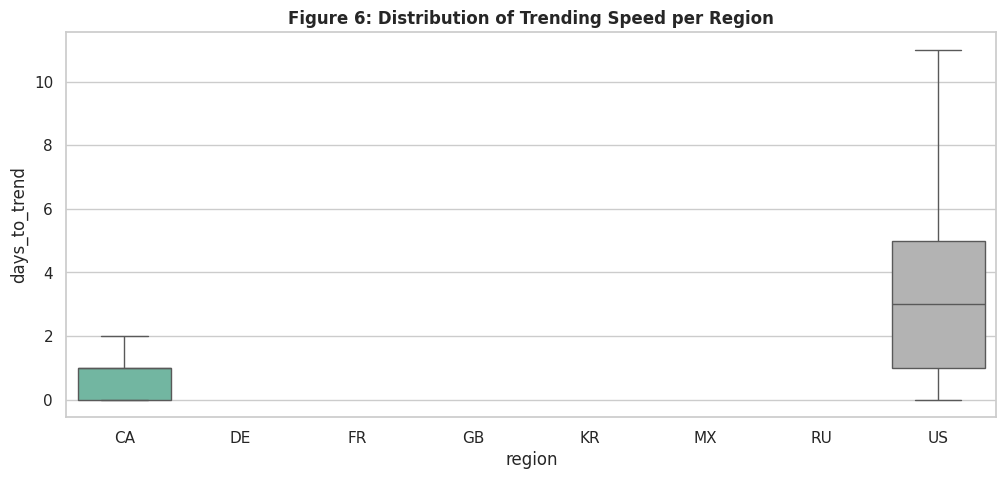

/tmp/ipykernel_847/2730004493.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='region', y='dislike_ratio', palette='Reds_r', estimator=np.mean)


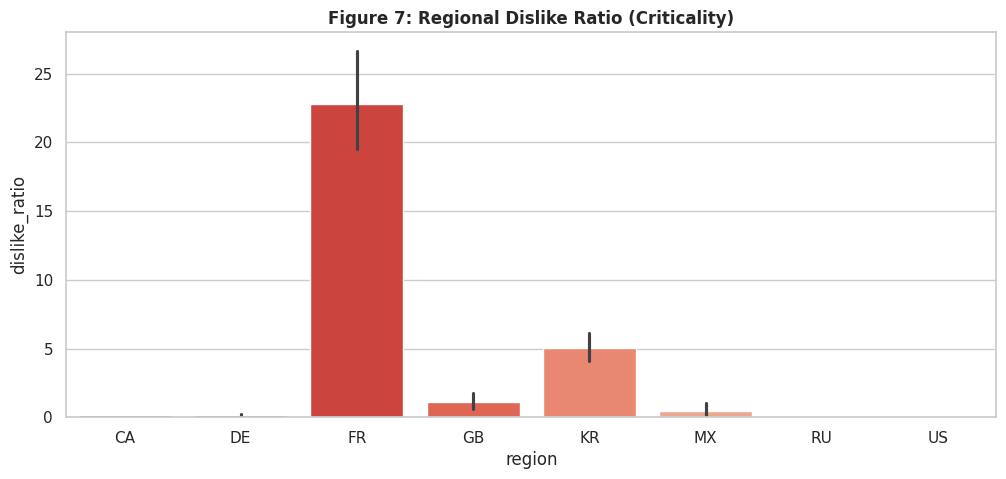

/tmp/ipykernel_847/2730004493.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=longevity_df, x='region', y='days_on_list', palette='plasma', estimator=np.mean)


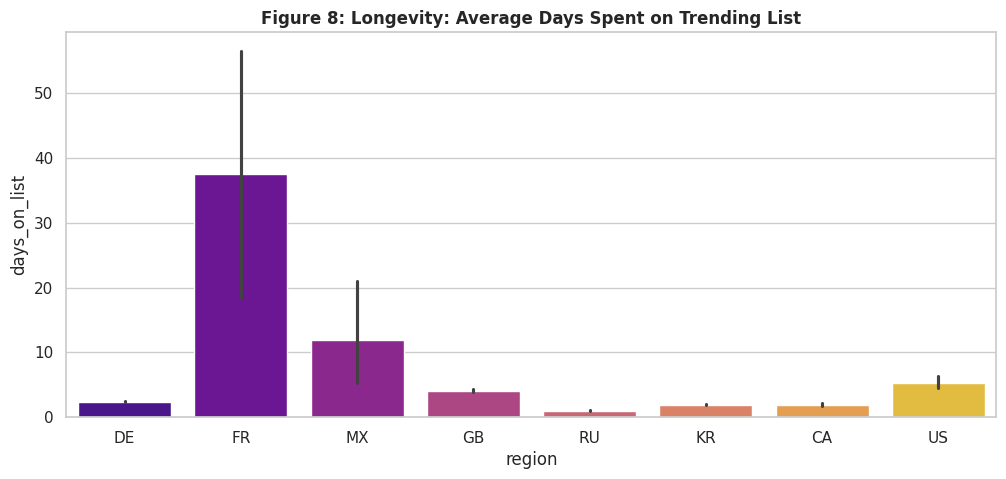

/tmp/ipykernel_847/2730004493.py:111: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='publish_day', order=day_order, palette='cool')


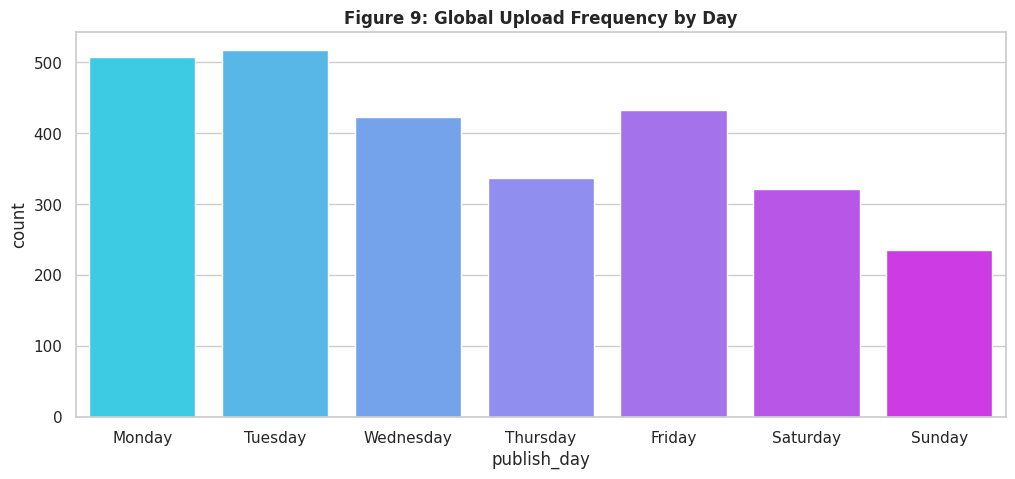

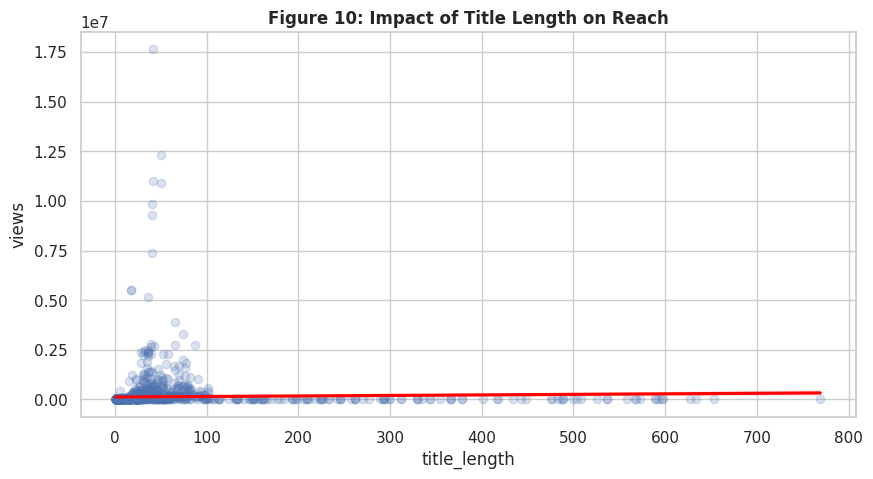

/tmp/ipykernel_847/2730004493.py:123: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='region', y='views', estimator=np.mean, palette='magma')


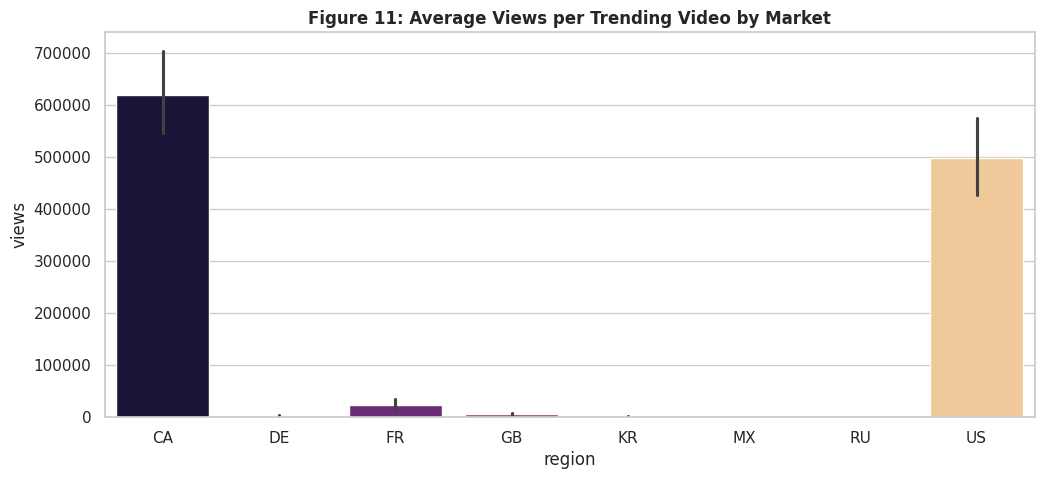


SUCCESS: Global analysis of 15843 records complete.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

countries = ['CA', 'DE', 'FR', 'GB', 'IN', 'JP', 'KR', 'MX', 'RU', 'US']
all_regions_df = []

print("Starting Universal Data Merge...")

try:
    for country in countries:
        csv_path = f'/content/{country}videos.csv'
        json_path = f'/content/{country}_category_id.json'

        if os.path.exists(csv_path) and os.path.exists(json_path):
            try:
                temp_df = pd.read_csv(csv_path, quoting=3, on_bad_lines='skip', engine='python', encoding='utf-8')
            except UnicodeDecodeError:
                temp_df = pd.read_csv(csv_path, quoting=3, on_bad_lines='skip', engine='python', encoding='ISO-8859-1')

            temp_df.columns = [c.replace('"', '').strip() for c in temp_df.columns]

            with open(json_path, 'r', encoding='utf-8', errors='ignore') as f:
                cat_data = json.load(f)
            id_to_cat = {item['id']: item['snippet']['title'] for item in cat_data['items']}
            temp_df['category_name'] = temp_df['category_id'].astype(str).map(id_to_cat)

            temp_df['region'] = country
            all_regions_df.append(temp_df)
            print(f"Loaded {country} successfully.")

    if not all_regions_df:
        print("\nCRITICAL: No files found.")
    else:
        df = pd.concat(all_regions_df, ignore_index=True)

        # --- DATA ENGINEERING ---
        df['trending_date'] = pd.to_datetime(df['trending_date'], format='%y.%d.%m', errors='coerce')
        df['publish_time'] = pd.to_datetime(df['publish_time'], errors='coerce').dt.tz_localize(None)
        df['days_to_trend'] = (df['trending_date'] - df['publish_time']).dt.days.clip(lower=0)
        df['publish_day'] = df['publish_time'].dt.day_name()
        df['title_length'] = df['title'].astype(str).str.len()

        numeric_cols = ['views', 'likes', 'dislikes', 'comment_count']
        for col in numeric_cols:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

        df['like_ratio'] = (df['likes'] / df['views']) * 100
        df['dislike_ratio'] = (df['dislikes'] / df['views']) * 100
        longevity_df = df.groupby(['video_id', 'region']).size().reset_index(name='days_on_list')

        # --- ALL 11 VISUALIZATIONS ---
        sns.set_theme(style="whitegrid")
        print("\nRendering All 11 Figures...")

        # 1. Global Categories
        plt.figure(figsize=(12, 5))
        sns.countplot(data=df, y='category_name', order=df['category_name'].value_counts().index, palette='magma')
        plt.title('Figure 1: Global Category Dominance', fontweight='bold')
        plt.show()

        # 2. Correlation Matrix
        plt.figure(figsize=(8, 6))
        sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
        plt.title('Figure 2: Engagement Synergy Heatmap', fontweight='bold')
        plt.show()

        # 3. Global Velocity
        plt.figure(figsize=(10, 5))
        sns.histplot(df[df['days_to_trend'] <= 14]['days_to_trend'], bins=15, kde=True, color='crimson')
        plt.title('Figure 3: Global Trending Velocity', fontweight='bold')
        plt.show()

        # 4. Regional Category Heatmap
        plt.figure(figsize=(12, 7))
        pivot = df.groupby(['category_name', 'region']).size().unstack().fillna(0)
        sns.heatmap(pivot / pivot.sum(), cmap="YlGnBu")
        plt.title('Figure 4: Category Interest by Country', fontweight='bold')
        plt.show()

        # 5. Like Ratio by Region
        plt.figure(figsize=(12, 5))
        sns.barplot(data=df, x='region', y='like_ratio', palette='viridis', estimator=np.median)
        plt.title('Figure 5: Median Like-to-View Ratio by Region', fontweight='bold')
        plt.show()

        # 6. Trending Speed Boxplot
        plt.figure(figsize=(12, 5))
        sns.boxplot(data=df, x='region', y='days_to_trend', palette='Set2', showfliers=False)
        plt.title('Figure 6: Distribution of Trending Speed per Region', fontweight='bold')
        plt.show()

        # 7. Dislike Ratio
        plt.figure(figsize=(12, 5))
        sns.barplot(data=df, x='region', y='dislike_ratio', palette='Reds_r', estimator=np.mean)
        plt.title('Figure 7: Regional Dislike Ratio (Criticality)', fontweight='bold')
        plt.show()

        # 8. Longevity
        plt.figure(figsize=(12, 5))
        sns.barplot(data=longevity_df, x='region', y='days_on_list', palette='plasma', estimator=np.mean)
        plt.title('Figure 8: Longevity: Average Days Spent on Trending List', fontweight='bold')
        plt.show()

        # 9. Upload Day
        plt.figure(figsize=(12, 5))
        day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
        sns.countplot(data=df, x='publish_day', order=day_order, palette='cool')
        plt.title('Figure 9: Global Upload Frequency by Day', fontweight='bold')
        plt.show()

        # 10. Title Length
        plt.figure(figsize=(10, 5))
        sns.regplot(data=df.sample(min(2000, len(df))), x='title_length', y='views', scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
        plt.title('Figure 10: Impact of Title Length on Reach', fontweight='bold')
        plt.show()

        # 11. Average Views per Region
        plt.figure(figsize=(12, 5))
        sns.barplot(data=df, x='region', y='views', estimator=np.mean, palette='magma')
        plt.title('Figure 11: Average Views per Trending Video by Market', fontweight='bold')
        plt.show()

        print(f"\nSUCCESS: Global analysis of {len(df)} records complete.")

except Exception as e:
    print(f"\nCRITICAL ERROR: {e}")

In [3]:
# --- NARRATIVE ANALYSIS DIGEST ---
print("--- START OF ANALYSIS DIGEST ---")

# 1. Volume and Reach
print("\n[REGIONAL VOLUME & ENGAGEMENT]")
digest_1 = df.groupby('region').agg({
    'video_id': 'count',
    'views': 'mean',
    'likes': 'mean',
    'dislikes': 'mean',
    'like_ratio': 'mean'
}).rename(columns={'video_id': 'total_trending_videos'})
print(digest_1.to_string())

# 2. Category Dominance
print("\n[TOP CATEGORIES PER REGIONAL MARKET]")
cat_pivot = df.groupby(['region', 'category_name']).size().unstack(fill_value=0)
top_cats = cat_pivot.idxmax(axis=1)
print(top_cats.to_string())

# 3. Trending Velocity
print("\n[AVERAGE DAYS TO TREND BY REGION]")
print(df.groupby('region')['days_to_trend'].median().to_string())

# 4. Global Category Stats
print("\n[GLOBAL CATEGORY PERFORMANCE]")
digest_2 = df.groupby('category_name').agg({
    'views': 'mean',
    'like_ratio': 'mean',
    'comment_count': 'mean'
}).sort_values(by='views', ascending=False)
print(digest_2.to_string())

# 5. Timing
print("\n[BEST PUBLISH DAYS FOR VIEWS]")
print(df.groupby('publish_day')['views'].mean().sort_values(ascending=False).to_string())

print("\n--- END OF ANALYSIS DIGEST ---")

--- START OF ANALYSIS DIGEST ---

[REGIONAL VOLUME & ENGAGEMENT]
        total_trending_videos          views         likes     dislikes  like_ratio
region                                                                             
CA                       1880  619517.550000  24980.216489  2325.902128    3.063252
DE                       2678    2618.333333    162.828609    16.500163         inf
FR                        900   23707.644491   1100.405405  1036.796258   13.070000
GB                        888    5403.554228   4018.675551   375.100184         inf
KR                       1749    1539.389286   1149.095408   164.142857         inf
MX                       1422     287.522529     25.880968     1.281775         inf
RU                       2659       0.177227      0.078105     0.000941   96.756757
US                       2209  497204.852875  19084.389316   774.302852    3.772544

[TOP CATEGORIES PER REGIONAL MARKET]
region
CA       Entertainment
DE       Entertainment
FR  